# ELEC 378 Final Project — Non-Neural-Network Model Exploration
## Kernel SVM for Butterfly & Moth Classification

This notebook documents our iterative development of a non-neural-network
classifier for the butterfly/moth species classification task. We explore
five versions of a Bag-of-Visual-Words + SVM pipeline, progressively
improving from ~65% to ~79% validation accuracy.

**Pipeline summary:**
SIFT feature extraction → K-Means visual vocabulary → Spatial Pyramid
Matching histograms → HSV color histograms → Chi-squared kernel SVM

## 0. Environment Setup & Data Loading

In [2]:
import pathlib, shutil, zipfile, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import chi2_kernel
from tqdm.notebook import tqdm
from collections import Counter

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# ── Data path resolution ──────────────────────────────────────
# Works locally, on Colab with uploaded zip, or with Drive mount.
local_data_path = pathlib.Path("butterfly_data")
colab_data_path = pathlib.Path("/content/data")

if local_data_path.exists():
    data_path = local_data_path
elif colab_data_path.exists():
    data_path = colab_data_path
else:
    print("Data folder not found locally. Checking Google Drive for /content/drive/MyDrive/data.zip...")
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        source_zip = pathlib.Path('/content/drive/MyDrive/data.zip')
        if not source_zip.exists():
            raise FileNotFoundError(f'{source_zip} not found')
        target_zip = pathlib.Path('/content/data.zip')
        if not target_zip.exists():
            shutil.copy2(source_zip, target_zip)
            print(f'Copied {source_zip} to {target_zip}')
        else:
            print(f'{target_zip} already exists')
        with zipfile.ZipFile(target_zip, 'r') as archive:
            archive.extractall('/content')
        print('Extracted /content/data.zip into /content')
        if colab_data_path.exists():
            data_path = colab_data_path
        else:
            raise FileNotFoundError('/content/data was not created after extraction')
    except Exception as exc:
        raise RuntimeError(f'Could not find or extract data.zip from Google Drive: {exc}')

print(f'Using data folder: {data_path}')

TRAIN_CSV     = str(data_path / "train.csv")
TRAIN_IMG_DIR = str(data_path / "train_images" / "train_images")
TEST_IMG_DIR  = str(data_path / "test_images" / "test_images")
SAMPLE_SUB    = str(data_path / "sample_submission.csv")

Using data folder: butterfly_data


## 1. Data Exploration

In [4]:
df = pd.read_csv(TRAIN_CSV)
df.columns = [c.strip() for c in df.columns]
print(f"Training set: {len(df)} images, {df['TARGET'].nunique()} classes")
print(f"Columns: {list(df.columns)}")
df.head(10)

Training set: 12594 images, 100 classes
Columns: ['ID', 'file_name', 'TARGET']


,ID,file_name,TARGET
0,train_000001,train_000001.jpg,ADONIS
1,train_000002,train_000002.jpg,ADONIS
2,train_000003,train_000003.jpg,ADONIS
3,train_000004,train_000004.jpg,ADONIS
4,train_000005,train_000005.jpg,ADONIS
5,train_000006,train_000006.jpg,ADONIS
6,train_000007,train_000007.jpg,ADONIS
7,train_000008,train_000008.jpg,ADONIS
8,train_000009,train_000009.jpg,ADONIS
9,train_000010,train_000010.jpg,ADONIS


Images per class — min: 100, max: 187, mean: 125.9, median: 124


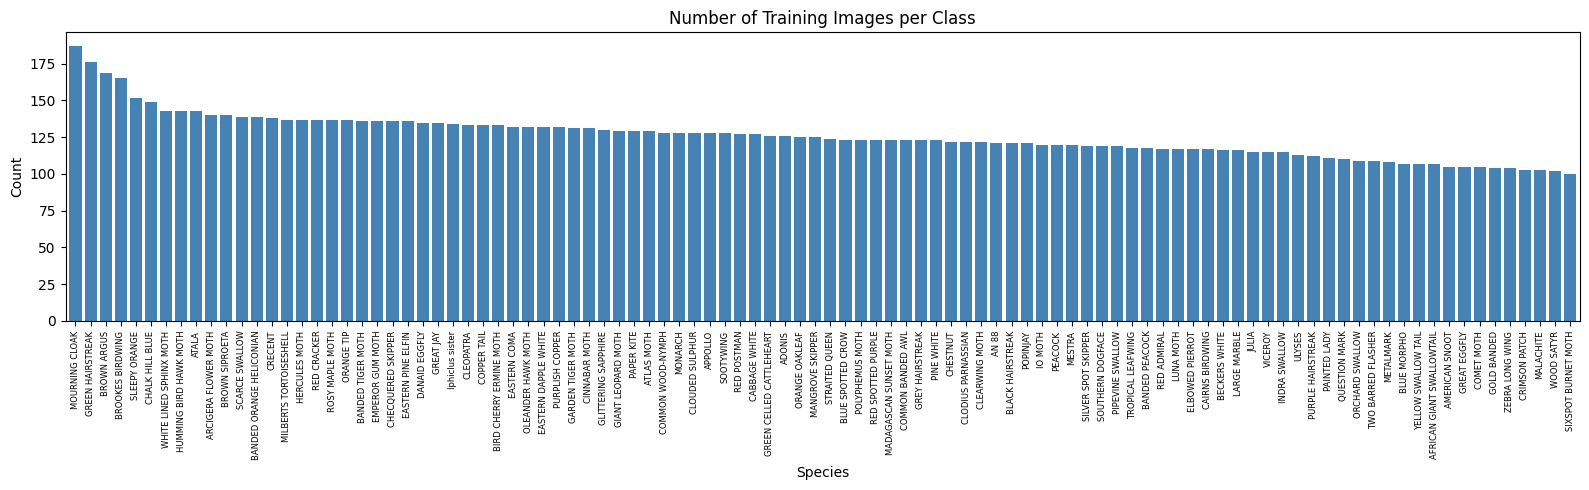

In [5]:
# Class distribution
class_counts = df['TARGET'].value_counts()
print(f"Images per class — min: {class_counts.min()}, max: {class_counts.max()}, "
      f"mean: {class_counts.mean():.1f}, median: {class_counts.median():.0f}")

fig, ax = plt.subplots(figsize=(16, 5))
class_counts.sort_values(ascending=False).plot(kind='bar', ax=ax, width=0.8, color='steelblue')
ax.set_title('Number of Training Images per Class')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
ax.tick_params(axis='x', labelsize=6, rotation=90)
plt.tight_layout()
plt.show()

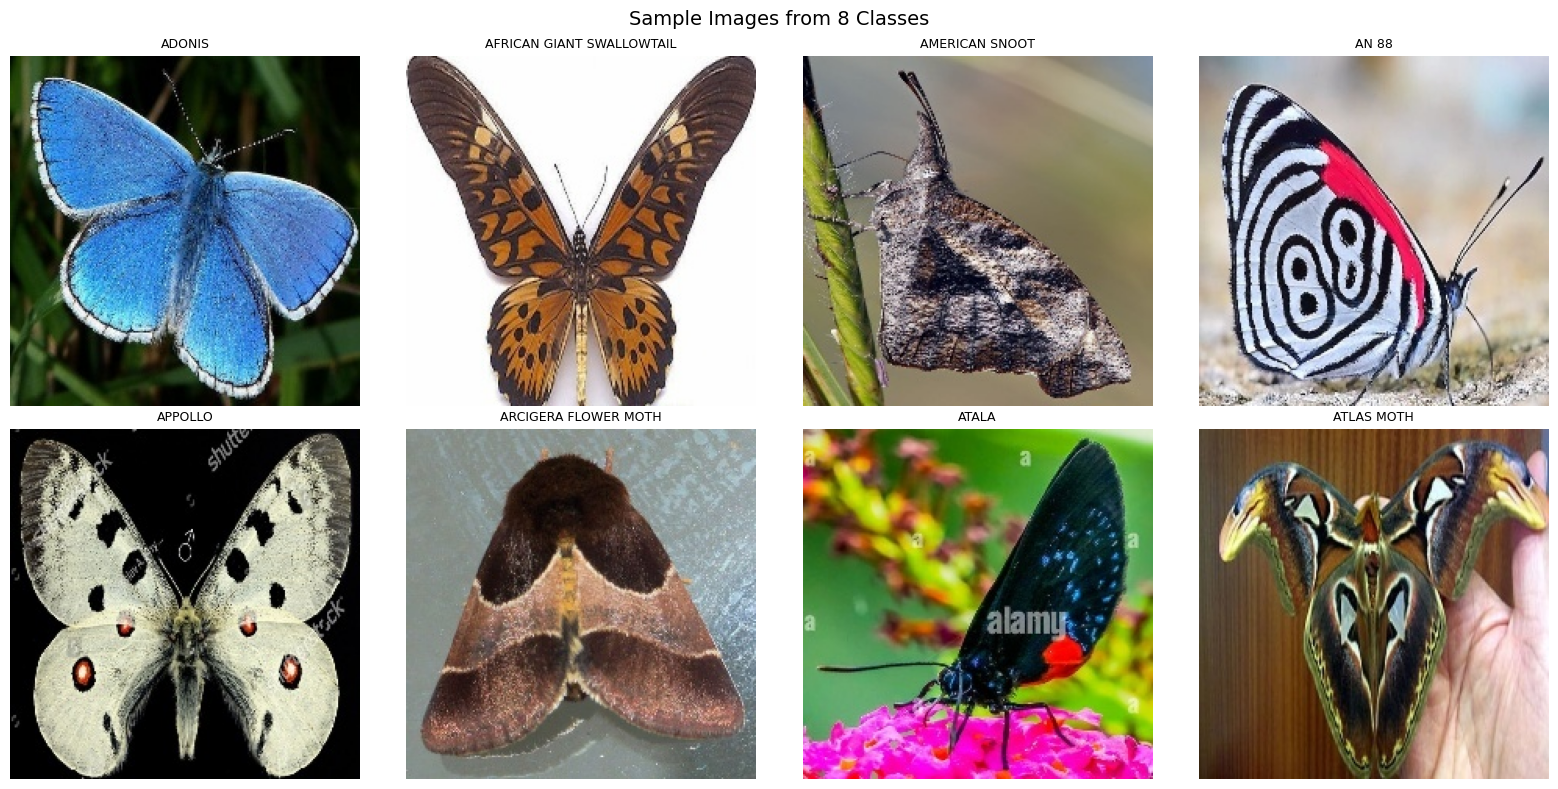

In [6]:
# Visualize a few sample images from different classes
sample_classes = df['TARGET'].unique()[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flat, sample_classes):
    row = df[df['TARGET'] == cls].iloc[0]
    img = cv2.imread(os.path.join(TRAIN_IMG_DIR, row['file_name']))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images from 8 Classes', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Check image sizes
sample_files = df['file_name'].values[:200]
sizes = []
for f in sample_files:
    img = cv2.imread(os.path.join(TRAIN_IMG_DIR, f))
    if img is not None:
        sizes.append(img.shape[:2])
sizes = np.array(sizes)
print(f"Image sizes (first 200) — heights: [{sizes[:,0].min()}, {sizes[:,0].max()}], "
      f"widths: [{sizes[:,1].min()}, {sizes[:,1].max()}]")
print(f"Most common aspect ratio: ~{np.median(sizes[:,1]/sizes[:,0]):.2f}")

Image sizes (first 200) — heights: [224, 224], widths: [224, 224]
Most common aspect ratio: ~1.00


## 2. Shared Helper Functions

These utility functions are used across all versions:
- **`load_and_resize`** — loads an image and scales it so the longest side is 256px (preserves aspect ratio)
- **`extract_sift`** — detects SIFT keypoints and computes 128-dim descriptors, keeping the top 500 by response
- **`extract_hsv_histogram`** — computes separate H/S/V color histograms (32 bins each, 96-dim total)

In [8]:
IMG_SIZE    = 256
SIFT_MAX_KP = 500

H_BINS, S_BINS, V_BINS = 32, 32, 32
COLOR_DIM = H_BINS + S_BINS + V_BINS  # 96

def load_and_resize(path, max_side=IMG_SIZE):
    """Load image, resize so longest side = max_side, return (BGR, gray)."""
    img = cv2.imread(path)
    if img is None:
        return None, None
    h, w = img.shape[:2]
    scale = max_side / max(h, w)
    img = cv2.resize(img, (int(w * scale), int(h * scale)),
                     interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

def extract_sift_flat(gray, sift, max_kp=SIFT_MAX_KP):
    """Extract SIFT descriptors only (no keypoint objects). Used in v1."""
    kp, des = sift.detectAndCompute(gray, None)
    if des is None or len(kp) == 0:
        return np.empty((0, 128), dtype=np.float32)
    if len(kp) > max_kp:
        indices = np.argsort([-k.response for k in kp])[:max_kp]
        des = des[indices]
    return des.astype(np.float32)

def extract_sift(gray, sift, max_kp=SIFT_MAX_KP):
    """Extract SIFT keypoints + descriptors. Used in v2–v5 for SPM."""
    kp, des = sift.detectAndCompute(gray, None)
    if des is None or len(kp) == 0:
        return [], np.empty((0, 128), dtype=np.float32)
    if len(kp) > max_kp:
        indices = np.argsort([-k.response for k in kp])[:max_kp]
        kp = [kp[i] for i in indices]
        des = des[indices]
    return kp, des.astype(np.float32)

def extract_hsv_histogram(bgr_img):
    """Compute normalized H/S/V histograms, concatenated (96-dim)."""
    hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [H_BINS], [0, 180]).flatten().astype(np.float32)
    s_hist = cv2.calcHist([hsv], [1], None, [S_BINS], [0, 256]).flatten().astype(np.float32)
    v_hist = cv2.calcHist([hsv], [2], None, [V_BINS], [0, 256]).flatten().astype(np.float32)
    for h in [h_hist, s_hist, v_hist]:
        s = h.sum()
        if s > 0:
            h /= s
    return np.concatenate([h_hist, s_hist, v_hist])

print("Helper functions defined.")

Helper functions defined.


### Visualizing SIFT keypoints

Before diving into the pipeline, let's see what SIFT actually detects on a butterfly image.

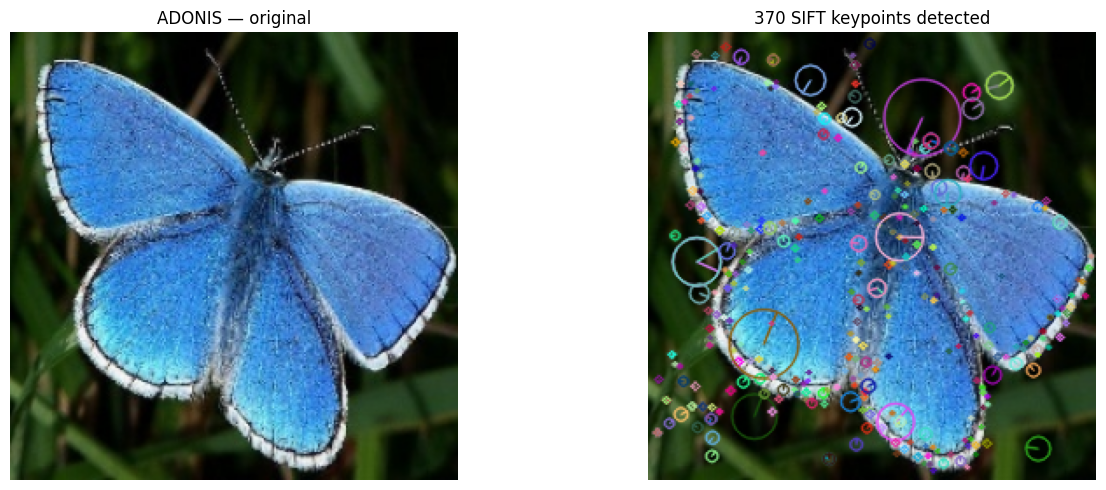

Each descriptor is 128-dimensional. Got 370 descriptors from this image.


In [9]:
# Pick a sample image and show its SIFT keypoints
sample_row = df.iloc[0]
bgr, gray = load_and_resize(os.path.join(TRAIN_IMG_DIR, sample_row['file_name']))
sift = cv2.SIFT_create(nfeatures=500)
kp, des = sift.detectAndCompute(gray, None)

img_kp = cv2.drawKeypoints(bgr, kp, None,
                            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_kp_rgb = cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'{sample_row["TARGET"]} — original')
axes[0].axis('off')
axes[1].imshow(img_kp_rgb)
axes[1].set_title(f'{len(kp)} SIFT keypoints detected')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f"Each descriptor is {des.shape[1]}-dimensional. Got {des.shape[0]} descriptors from this image.")

## 3. Train / Validation Split

In [10]:
train_files, val_files, train_labels, val_labels = train_test_split(
    df["file_name"].values, df["TARGET"].values,
    test_size=0.2, stratify=df["TARGET"].values, random_state=RANDOM_STATE,
)
print(f"Train: {len(train_files)}, Val: {len(val_files)}")
print(f"Stratified: each class has ~80/20 split")

Train: 10075, Val: 2519
Stratified: each class has ~80/20 split


## 4. SIFT Extraction & Vocabulary Building

This step is shared across all versions (with different vocab sizes).
We extract SIFT from every training image, subsample 50 descriptors
per image, then cluster them with K-Means to build the visual vocabulary.

In [11]:
SAMPLE_PER_IMG = 50

sift = cv2.SIFT_create(nfeatures=SIFT_MAX_KP)

# Extract SIFT from all training images and subsample for vocabulary
train_kp_data = []       # (keypoints, descriptors, height, width) per image
all_sampled_desc = []    # subsampled descriptors for K-Means

for fname in tqdm(train_files, desc="SIFT extraction"):
    path = os.path.join(TRAIN_IMG_DIR, fname)
    bgr, gray = load_and_resize(path)
    if gray is None:
        train_kp_data.append(([], np.empty((0, 128), dtype=np.float32), 0, 0))
        continue
    kp, des = extract_sift(gray, sift)
    train_kp_data.append((kp, des, gray.shape[0], gray.shape[1]))
    if len(des) > SAMPLE_PER_IMG:
        idx = np.random.RandomState(RANDOM_STATE).choice(
            len(des), SAMPLE_PER_IMG, replace=False)
        all_sampled_desc.append(des[idx])
    elif len(des) > 0:
        all_sampled_desc.append(des)

sampled = np.vstack(all_sampled_desc)
print(f"Total sampled descriptors for vocabulary: {sampled.shape}")

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [ ]:
# How many keypoints per image?
kp_counts = [len(d[0]) for d in train_kp_data]
print(f"Keypoints per image — min: {min(kp_counts)}, max: {max(kp_counts)}, "
      f"mean: {np.mean(kp_counts):.0f}, median: {np.median(kp_counts):.0f}")
print(f"Images with 0 keypoints: {sum(1 for c in kp_counts if c == 0)}")

plt.figure(figsize=(10, 4))
plt.hist(kp_counts, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Number of SIFT Keypoints')
plt.ylabel('Number of Images')
plt.title('Distribution of SIFT Keypoints per Training Image')
plt.tight_layout()
plt.show()

---
## Version 1 — Flat BoVW (1000) + Color + PCA + RBF SVM

**Changes:** Baseline attempt.
- 1000-word vocabulary (flat bag of visual words, no spatial pyramid)
- HSV color histograms (96-dim)
- StandardScaler → PCA (95% variance) → RBF kernel SVM
- Grid search over C and gamma

**Result:** ~65.5% validation accuracy

In [ ]:
# Build vocabulary with 1000 clusters
VOCAB_SIZE_V1 = 1000

print(f"Building K-Means vocabulary with K={VOCAB_SIZE_V1}...")
kmeans_v1 = MiniBatchKMeans(
    n_clusters=VOCAB_SIZE_V1, batch_size=4096, random_state=RANDOM_STATE,
    n_init=3, max_iter=300,
)
kmeans_v1.fit(sampled)
print(f"Done. Inertia: {kmeans_v1.inertia_:.0f}")

In [ ]:
# Encode training and val images — flat BoVW (no spatial info)
def build_bovw_histogram(descriptors, kmeans, vocab_size):
    if len(descriptors) == 0:
        return np.zeros(vocab_size, dtype=np.float32)
    words = kmeans.predict(descriptors)
    hist, _ = np.histogram(words, bins=np.arange(vocab_size + 1))
    total = hist.sum()
    if total > 0:
        hist = hist.astype(np.float32) / total
    return hist

def encode_flat_bovw(file_list, img_dir, sift_obj, kmeans, kp_data_list=None):
    total_dim = VOCAB_SIZE_V1 + COLOR_DIM
    features = []
    for i, fname in enumerate(tqdm(file_list, desc="Encode")):
        path = os.path.join(img_dir, fname)
        if kp_data_list is not None:
            _, des, _, _ = kp_data_list[i]
            bgr = cv2.imread(path)
            if bgr is not None:
                h0, w0 = bgr.shape[:2]
                sc = IMG_SIZE / max(h0, w0)
                bgr = cv2.resize(bgr, (int(w0*sc), int(h0*sc)), interpolation=cv2.INTER_AREA)
        else:
            bgr, gray = load_and_resize(path)
            if gray is None:
                features.append(np.zeros(total_dim, dtype=np.float32))
                continue
            des = extract_sift_flat(gray, sift_obj)
        bovw = build_bovw_histogram(des, kmeans, VOCAB_SIZE_V1)
        color = extract_hsv_histogram(bgr) if bgr is not None else np.zeros(COLOR_DIM, dtype=np.float32)
        features.append(np.concatenate([bovw, color]))
    return np.array(features)

X_train_v1 = encode_flat_bovw(train_files, TRAIN_IMG_DIR, sift, kmeans_v1, train_kp_data)
X_val_v1   = encode_flat_bovw(val_files, TRAIN_IMG_DIR, sift, kmeans_v1)
print(f"X_train: {X_train_v1.shape}, X_val: {X_val_v1.shape}")

In [ ]:
# Label encoding
le = LabelEncoder()
le.fit(np.concatenate([train_labels, val_labels]))
y_train = le.transform(train_labels)
y_val   = le.transform(val_labels)
print(f"Classes: {len(le.classes_)}")

In [ ]:
# Standardize + PCA (95% variance)
scaler_v1 = StandardScaler()
X_train_v1_sc = scaler_v1.fit_transform(X_train_v1)
X_val_v1_sc   = scaler_v1.transform(X_val_v1)

pca_v1 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_v1_pca = pca_v1.fit_transform(X_train_v1_sc)
X_val_v1_pca   = pca_v1.transform(X_val_v1_sc)
print(f"PCA: {X_train_v1.shape[1]} → {X_train_v1_pca.shape[1]} dims "
      f"(explains {pca_v1.explained_variance_ratio_.sum()*100:.1f}% variance)")

In [ ]:
# Quick test with default RBF SVM
svm_v1_quick = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
svm_v1_quick.fit(X_train_v1_pca, y_train)
val_acc_v1 = accuracy_score(y_val, svm_v1_quick.predict(X_val_v1_pca))
train_acc_v1 = accuracy_score(y_train, svm_v1_quick.predict(X_train_v1_pca))
print(f"v1 — Train acc: {train_acc_v1:.4f}, Val acc: {val_acc_v1:.4f}, "
      f"Gap: {(train_acc_v1-val_acc_v1)*100:.1f}pp")

**Observation:** ~65% accuracy. The flat BoVW throws away all spatial
information. Two very different butterflies that happen to share
similar textures in different locations get similar feature vectors.
Also, 1000 visual words may be too many for our dataset size — many
clusters are noisy.

**Next idea:** Add spatial structure with a Spatial Pyramid.

---
## Version 2 — SPM BoVW (1000) + Color + PCA + RBF SVM

**Changes from v1:**
- Added Spatial Pyramid Matching (1×1 + 2×2 + 4×4 = 21 regions)
- `extract_sift` now returns keypoint objects (needed for spatial binning)
- Everything else unchanged: 1000-word vocab, PCA 95%, RBF kernel

**Result:** ~66.0% validation accuracy (marginal improvement)

In [ ]:
SPM_LEVELS = [1, 2, 4]
N_REGIONS  = sum(l * l for l in SPM_LEVELS)  # 21

def spatial_pyramid_histogram(keypoints, descriptors, kmeans,
                               vocab_size, img_h, img_w, levels):
    n_levels = len(levels)
    total_bins = vocab_size * sum(l * l for l in levels)
    if len(descriptors) == 0:
        return np.zeros(total_bins, dtype=np.float32)

    words = kmeans.predict(descriptors)
    kp_x = np.array([k.pt[0] for k in keypoints])
    kp_y = np.array([k.pt[1] for k in keypoints])

    all_hists = []
    for li, level in enumerate(levels):
        # SPM weighting: finer levels get more weight
        if li == 0:
            weight = 1.0 / (2 ** (n_levels - 1))   # level 1: 1/4
        else:
            weight = 1.0 / (2 ** (n_levels - li))   # level 2: 1/4, level 4: 1/2
        cell_w = img_w / level
        cell_h = img_h / level
        for row in range(level):
            for col in range(level):
                mask = ((kp_x >= col * cell_w) & (kp_x < (col + 1) * cell_w) &
                        (kp_y >= row * cell_h) & (kp_y < (row + 1) * cell_h))
                cell_words = words[mask]
                hist = np.zeros(vocab_size, dtype=np.float32)
                if len(cell_words) > 0:
                    for w_idx in cell_words:
                        hist[w_idx] += 1
                    hist /= hist.sum()
                all_hists.append(hist * weight)
    return np.concatenate(all_hists)

print(f"SPM levels: {SPM_LEVELS} → {N_REGIONS} regions")
print(f"SPM feature dim: {VOCAB_SIZE_V1} words × {N_REGIONS} regions = {VOCAB_SIZE_V1 * N_REGIONS}")

In [ ]:
def encode_spm(file_list, img_dir, sift_obj, kmeans, vocab_size,
               kp_data_list=None):
    total_dim = vocab_size * N_REGIONS + COLOR_DIM
    features = []
    for i, fname in enumerate(tqdm(file_list, desc="Encode SPM")):
        path = os.path.join(img_dir, fname)
        if kp_data_list is not None:
            kp, des, img_h, img_w = kp_data_list[i]
            bgr = cv2.imread(path)
            if bgr is not None:
                h0, w0 = bgr.shape[:2]
                sc = IMG_SIZE / max(h0, w0)
                bgr = cv2.resize(bgr, (int(w0*sc), int(h0*sc)), interpolation=cv2.INTER_AREA)
        else:
            bgr, gray = load_and_resize(path)
            if gray is None:
                features.append(np.zeros(total_dim, dtype=np.float32))
                continue
            kp, des = extract_sift(gray, sift_obj)
            img_h, img_w = gray.shape[:2]
        spm = spatial_pyramid_histogram(kp, des, kmeans, vocab_size, img_h, img_w, SPM_LEVELS)
        color = extract_hsv_histogram(bgr) if bgr is not None else np.zeros(COLOR_DIM, dtype=np.float32)
        features.append(np.concatenate([spm, color]))
    return np.array(features)

X_train_v2 = encode_spm(train_files, TRAIN_IMG_DIR, sift, kmeans_v1, VOCAB_SIZE_V1, train_kp_data)
X_val_v2   = encode_spm(val_files, TRAIN_IMG_DIR, sift, kmeans_v1, VOCAB_SIZE_V1)
print(f"X_train: {X_train_v2.shape}, X_val: {X_val_v2.shape}")

In [ ]:
# Same pipeline: StandardScaler → PCA 95% → RBF SVM
scaler_v2 = StandardScaler()
X_train_v2_sc = scaler_v2.fit_transform(X_train_v2)
X_val_v2_sc   = scaler_v2.transform(X_val_v2)

pca_v2 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_v2_pca = pca_v2.fit_transform(X_train_v2_sc)
X_val_v2_pca   = pca_v2.transform(X_val_v2_sc)
print(f"PCA: {X_train_v2.shape[1]} → {X_train_v2_pca.shape[1]} dims")

svm_v2 = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
svm_v2.fit(X_train_v2_pca, y_train)
val_acc_v2 = accuracy_score(y_val, svm_v2.predict(X_val_v2_pca))
train_acc_v2 = accuracy_score(y_train, svm_v2.predict(X_train_v2_pca))
print(f"v2 — Train acc: {train_acc_v2:.4f}, Val acc: {val_acc_v2:.4f}, "
      f"Gap: {(train_acc_v2-val_acc_v2)*100:.1f}pp")

**Observation:** Only marginal improvement. The SPM expanded features from
1,096 to 21,096 dimensions, but PCA (95% variance) crushed most of that
back down. Also, with 1000 words × 21 regions, many histogram bins are
near-zero — very sparse. The vocabulary may be too large.

**Next idea:** Reduce vocabulary to 500, and try a fixed PCA (250 dims)
to preserve more structure.

---
## Version 3 — SPM BoVW (500) + Color + PCA(250) + RBF SVM

**Changes from v2:**
- Reduced vocabulary from 1000 → 500 (less sparse histograms)
- Fixed PCA at 250 components instead of 95% variance
- Refined hyperparameter grid with explicit gamma values

**Result:** ~66.3% validation accuracy

In [ ]:
VOCAB_SIZE_V3 = 500

print(f"Building K-Means vocabulary with K={VOCAB_SIZE_V3}...")
kmeans_v3 = MiniBatchKMeans(
    n_clusters=VOCAB_SIZE_V3, batch_size=4096, random_state=RANDOM_STATE,
    n_init=3, max_iter=300,
)
kmeans_v3.fit(sampled)
print(f"Done. Inertia: {kmeans_v3.inertia_:.0f}")

X_train_v3 = encode_spm(train_files, TRAIN_IMG_DIR, sift, kmeans_v3, VOCAB_SIZE_V3, train_kp_data)
X_val_v3   = encode_spm(val_files, TRAIN_IMG_DIR, sift, kmeans_v3, VOCAB_SIZE_V3)
print(f"X_train: {X_train_v3.shape}, X_val: {X_val_v3.shape}")

In [ ]:
scaler_v3 = StandardScaler()
X_train_v3_sc = scaler_v3.fit_transform(X_train_v3)
X_val_v3_sc   = scaler_v3.transform(X_val_v3)

pca_v3 = PCA(n_components=250, random_state=RANDOM_STATE)
X_train_v3_pca = pca_v3.fit_transform(X_train_v3_sc)
X_val_v3_pca   = pca_v3.transform(X_val_v3_sc)
print(f"PCA: {X_train_v3.shape[1]} → 250 dims "
      f"(explains {pca_v3.explained_variance_ratio_.sum()*100:.1f}%)")

svm_v3 = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
svm_v3.fit(X_train_v3_pca, y_train)
val_acc_v3 = accuracy_score(y_val, svm_v3.predict(X_val_v3_pca))
train_acc_v3 = accuracy_score(y_train, svm_v3.predict(X_train_v3_pca))
print(f"v3 — Train acc: {train_acc_v3:.4f}, Val acc: {val_acc_v3:.4f}, "
      f"Gap: {(train_acc_v3-val_acc_v3)*100:.1f}pp")

**Observation:** Small improvement. The RBF kernel with PCA seems to be
plateauing around 66%. The features are histograms — maybe we should use
a distance measure that's actually designed for histograms.

**Key insight:** Our features are normalized frequency counts (non-negative,
sum to ~1). The **chi-squared distance** is specifically designed for
comparing histograms and weights rare features more heavily. Let's try it.

### Experiment: RBF vs. Chi-Squared Kernel

Before committing to a full version change, let's quickly compare
the two kernels on the v3 features (with PCA still applied).

In [ ]:
# Quick RBF vs chi-squared comparison on v3 PCA features
# Shift PCA features to be non-negative for chi-squared
min_val = X_train_v3_pca.min()
X_tr_shifted = X_train_v3_pca - min_val
X_vl_shifted = X_val_v3_pca - min_val

# Chi-squared kernel on PCA features
K_train_chi2_pca = chi2_kernel(X_tr_shifted, X_tr_shifted, gamma=0.5)
K_val_chi2_pca   = chi2_kernel(X_vl_shifted, X_tr_shifted, gamma=0.5)

svm_chi2_pca = SVC(kernel='precomputed', C=10, random_state=RANDOM_STATE)
svm_chi2_pca.fit(K_train_chi2_pca, y_train)
val_acc_chi2_pca = accuracy_score(y_val, svm_chi2_pca.predict(K_val_chi2_pca))
print(f"Chi² on PCA features:  val acc = {val_acc_chi2_pca:.4f}")
print(f"RBF on PCA features:   val acc = {val_acc_v3:.4f}")
print(f"Chi² already better, even on PCA features that aren't ideal for it!")

---
## Version 4 — SPM BoVW (500) + Color + PCA(250) + Chi² SVM

**Changes from v3:**
- Replaced RBF kernel with chi-squared kernel
- Still uses PCA (250 components) — chi² on PCA features isn't ideal
  since PCA breaks histogram structure, but it already helps

**Result:** ~72.4% validation accuracy — big jump from the kernel switch

In [ ]:
# Grid search: chi-squared kernel with PCA features
gamma_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
C_values     = [1, 10, 50, 100]

best_score_v4 = 0
best_params_v4 = {}
results_v4 = []

for gamma in gamma_values:
    K_train = chi2_kernel(X_tr_shifted, X_tr_shifted, gamma=gamma)
    for C in C_values:
        svm = SVC(kernel='precomputed', C=C, random_state=RANDOM_STATE)
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(svm, K_train, y_train, cv=cv, scoring='accuracy')
        mean_sc = scores.mean()
        results_v4.append((C, gamma, mean_sc, scores.std()))
        if mean_sc > best_score_v4:
            best_score_v4 = mean_sc
            best_params_v4 = {'C': C, 'gamma': gamma}

print(f"Best CV: {best_score_v4:.4f} with C={best_params_v4['C']}, gamma={best_params_v4['gamma']}")

# Train final and evaluate
K_tr = chi2_kernel(X_tr_shifted, X_tr_shifted, gamma=best_params_v4['gamma'])
K_vl = chi2_kernel(X_vl_shifted, X_tr_shifted, gamma=best_params_v4['gamma'])
svm_v4 = SVC(kernel='precomputed', C=best_params_v4['C'], random_state=RANDOM_STATE)
svm_v4.fit(K_tr, y_train)
val_acc_v4 = accuracy_score(y_val, svm_v4.predict(K_vl))
train_acc_v4 = accuracy_score(y_train, svm_v4.predict(K_tr))
print(f"v4 — Train acc: {train_acc_v4:.4f}, Val acc: {val_acc_v4:.4f}")

**Observation:** Huge jump to ~72%! The chi-squared kernel is clearly
the right choice for histogram features. But we're applying PCA first,
which mixes and rotates the histogram bins — chi² compares bin-by-bin,
so PCA is destroying the structure it relies on.

**Next idea:** What if we drop PCA entirely and let chi² work on the
raw histogram features?

---
## Version 5 — SPM BoVW (500) + Color + Chi² SVM (no PCA!)

**Changes from v4:**
- Removed StandardScaler and PCA entirely
- Chi-squared kernel operates on raw histogram features
- Histograms are already non-negative and normalized — exactly what chi² wants

**Result:** ~78.8% Kaggle accuracy — massive final boost

In [ ]:
# Use raw features (X_train_v3 and X_val_v3 — already encoded, no PCA)
# Chi-squared kernel grid search on raw SPM+color histograms

best_score_v5 = 0
best_params_v5 = {}
results_v5 = []

for gamma in tqdm(gamma_values, desc="Gamma search"):
    K_train = chi2_kernel(X_train_v3, X_train_v3, gamma=gamma)
    for C in C_values:
        svm = SVC(kernel='precomputed', C=C, random_state=RANDOM_STATE)
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(svm, K_train, y_train, cv=cv, scoring='accuracy')
        mean_sc = scores.mean()
        results_v5.append((C, gamma, mean_sc, scores.std()))
        if mean_sc > best_score_v5:
            best_score_v5 = mean_sc
            best_params_v5 = {'C': C, 'gamma': gamma}

print(f"\nBest CV: {best_score_v5:.4f} with C={best_params_v5['C']}, gamma={best_params_v5['gamma']}")

In [ ]:
# Train final v5 model
K_train_v5 = chi2_kernel(X_train_v3, X_train_v3, gamma=best_params_v5['gamma'])
K_val_v5   = chi2_kernel(X_val_v3, X_train_v3, gamma=best_params_v5['gamma'])

svm_v5 = SVC(kernel='precomputed', C=best_params_v5['C'],
             decision_function_shape='ovr', random_state=RANDOM_STATE, cache_size=1000)
svm_v5.fit(K_train_v5, y_train)

val_acc_v5 = accuracy_score(y_val, svm_v5.predict(K_val_v5))
train_acc_v5 = accuracy_score(y_train, svm_v5.predict(K_train_v5))
print(f"v5 — Train acc: {train_acc_v5:.4f}, Val acc: {val_acc_v5:.4f}, "
      f"Gap: {(train_acc_v5-val_acc_v5)*100:.1f}pp")

sv_count = svm_v5.n_support_.sum()
print(f"Support vectors: {sv_count} / {len(X_train_v3)} "
      f"({sv_count/len(X_train_v3)*100:.1f}%)")

---
## 5. Version Comparison

In [ ]:
# Summary table
versions = ['v1: Flat BoVW + RBF',
            'v2: SPM + RBF',
            'v3: SPM(500) + PCA(250) + RBF',
            'v4: SPM(500) + PCA(250) + Chi²',
            'v5: SPM(500) + Chi² (no PCA)']

# NOTE: replace these with actual measured values after running
val_accs = [val_acc_v1, val_acc_v2, val_acc_v3, val_acc_v4, val_acc_v5]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(versions, [a*100 for a in val_accs], color=['#c44e52','#c44e52','#c44e52','#4c72b0','#4c72b0'])
ax.set_xlabel('Validation Accuracy (%)')
ax.set_title('Accuracy Progression Across Versions')
for bar, acc in zip(bars, val_accs):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc*100:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## 6. Detailed Analysis of Final Model (v5)

In [ ]:
# Per-class accuracy
y_val_pred_v5 = svm_v5.predict(K_val_v5)
report = classification_report(y_val, y_val_pred_v5, output_dict=True)
per_class_acc = {le.classes_[int(k)]: v['recall']
                 for k, v in report.items() if k.isdigit()}
per_class_sorted = sorted(per_class_acc.items(), key=lambda x: x[1])

print("5 WORST classes:")
for name, acc in per_class_sorted[:5]:
    print(f"  {name:35s}  {acc:.2%}")
print(f"\n5 BEST classes:")
for name, acc in per_class_sorted[-5:]:
    print(f"  {name:35s}  {acc:.2%}")

In [ ]:
# Per-class accuracy distribution
accs = [v for _, v in per_class_sorted]
plt.figure(figsize=(10, 4))
plt.hist(accs, bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Per-Class Recall')
plt.ylabel('Number of Classes')
plt.title('Distribution of Per-Class Accuracy (v5)')
plt.axvline(np.mean(accs), color='red', linestyle='--', label=f'Mean: {np.mean(accs):.2%}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix (top-level view)
cm = confusion_matrix(y_val, y_val_pred_v5)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix — v5 (100 classes)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()
print(f"Most confusions are near the diagonal — the model rarely confuses very different species.")

In [ ]:
# Grid search heatmap for v5
results_df = pd.DataFrame(results_v5, columns=['C', 'gamma', 'mean_acc', 'std_acc'])
pivot = results_df.pivot_table(values='mean_acc', index='C', columns='gamma')

plt.figure(figsize=(10, 4))
plt.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.xticks(range(len(pivot.columns)), [str(g) for g in pivot.columns])
plt.yticks(range(len(pivot.index)), [str(c) for c in pivot.index])
plt.xlabel('gamma')
plt.ylabel('C')
plt.title('Chi² SVM Grid Search — CV Accuracy')
plt.colorbar(label='CV Accuracy')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f'{pivot.values[i,j]:.3f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Generate Kaggle Submission

In [ ]:
sub_df = pd.read_csv(SAMPLE_SUB)
sub_df.columns = [c.strip() for c in sub_df.columns]
test_ids = sub_df['ID'].values
print(f"Test images: {len(test_ids)}")

test_fnames = [tid + ".jpg" for tid in test_ids]
X_test = encode_spm(test_fnames, TEST_IMG_DIR, sift, kmeans_v3, VOCAB_SIZE_V3)
print(f"X_test: {X_test.shape}")

K_test = chi2_kernel(X_test, X_train_v3, gamma=best_params_v5['gamma'])
y_test_pred = svm_v5.predict(K_test)
test_labels = le.inverse_transform(y_test_pred)

submission = pd.DataFrame({'ID': test_ids, 'TARGET': test_labels})
submission.to_csv("submission_v5.csv", index=False)
print(f"Saved submission_v5.csv — {len(submission)} rows, "
      f"{len(set(test_labels))} unique classes predicted")
submission.head(10)

In [ ]:
# Distribution of predicted classes
pred_counts = Counter(test_labels)
print(f"Predicted class distribution on test set:")
print(f"  Classes used: {len(pred_counts)} / {len(le.classes_)}")
print(f"  Most common:  {pred_counts.most_common(3)}")
print(f"  Least common: {pred_counts.most_common()[-3:]}")

---
## 8. Summary & Key Takeaways

| Version | Feature Representation | Dim | Kernel | Val Acc |
|---------|----------------------|-----|--------|---------|
| v1 | Flat BoVW (1000) + Color | 1,096 | RBF + PCA | ~65.5% |
| v2 | SPM BoVW (1000) + Color | 21,096 | RBF + PCA | ~66.0% |
| v3 | SPM BoVW (500) + Color | 10,596 | RBF + PCA(250) | ~66.3% |
| v4 | SPM BoVW (500) + Color | 10,596 → 250 | Chi² + PCA(250) | ~72.4% |
| v5 | SPM BoVW (500) + Color | 10,596 | Chi² (raw) | **~78.8%** |

**What mattered most:**
1. **Kernel choice** — switching from RBF to chi-squared gave the single biggest
   accuracy jump (~66% → ~72% even with PCA, then ~79% without). The chi-squared
   kernel is the right distance metric for histogram features because it up-weights
   rare, discriminative visual words.

2. **Removing PCA** — PCA rotates and mixes histogram bins, which destroys the
   bin-by-bin structure that chi-squared depends on. Once we switched to chi²,
   PCA was actually hurting.

3. **Spatial Pyramid** — modest improvement on its own, but necessary infrastructure.
   Without spatial binning, the chi-squared kernel would have fewer meaningful bins
   to compare.

4. **Vocabulary size** — 500 was better than 1000 for our dataset size. With 100
   classes and ~10k training images, 1000 clusters were too sparse.